In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd drive/MyDrive/DATA

/content/drive/MyDrive/DATA


In [4]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# ====== 1. Пути к файлам ======
BASE_FILE = "frccsc_processed.csv"

CLUSTER_FILES = {
    "PREP (K-Means)":   "path_processed/frccsc_processed_prep_kmeans.csv",
    "PREP (0-1 matrix)":"path_processed/frccsc_processed_prep_01.csv",
    "BERT":             "path_processed2/frccsc_processed_bert.csv",
    "TF-IDF":           "path_processed2/frccsc_processed_tfidf.csv",
    "Word2Vec":         "path_processed2/frccsc_processed_w2v.csv",
    "Struct":           "path_processed/frccsc_processed_struct.csv",
}

TARGET_COL = "ElapsedRaw"

# ====== 2. Загрузка базового файла ======
df_base = pd.read_csv(BASE_FILE)
print("Базовый файл:", df_base.shape)

# Целевая переменная
y = df_base[TARGET_COL].values

# Столбцы, которые НЕ используем как признаки
drop_cols_common = ["State", "WorkDir_clean", "Start", "End", TARGET_COL]

# Признаки для baseline-модели: WorkDir оставляем
feature_cols_base = [c for c in df_base.columns if c not in drop_cols_common]

# Признаки для моделей с кластерами: WorkDir убираем
feature_cols_clust_base = [c for c in feature_cols_base if c != "WorkDir"]

print("Признаков в baseline-модели:", len(feature_cols_base))
print("Список baseline-признаков:", feature_cols_base)

# ====== 3. Общее разбиение train/test (одинаковое для всех моделей) ======
indices = np.arange(len(df_base))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, shuffle=True
)

def make_splits(df, feature_cols):
    X = df[feature_cols]
    X_train = X.loc[train_idx].reset_index(drop=True)
    X_test  = X.loc[test_idx].reset_index(drop=True)
    y_train = y[train_idx]
    y_test  = y[test_idx]
    return X_train, X_test, y_train, y_test

# ====== 4. Функция для обучения и оценки модели ======
def build_and_evaluate(X_train, X_test, y_train, y_test, desc=""):
    # Отделяем числовые и категориальные признаки
    num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

    print(f"\n[{desc}]")
    print("  Числовые признаки :", num_cols)
    print("  Категориальные    :", cat_cols)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ],
        remainder="drop",
    )

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    # Обучение
    print(X_train.columns[X_train.columns.duplicated()])
    pipe.fit(X_train, y_train)

    # Предсказание
    y_pred = pipe.predict(X_test)

    # Метрики

    def runtime_accuracy(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)

        if np.any(y_true <= 0) or np.any(y_pred <= 0):
            raise ValueError("Метрика определена только для положительных runtime.")

        acc_i = np.minimum(y_true, y_pred) / np.maximum(y_true, y_pred)
        return acc_i.mean()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    accuracy = runtime_accuracy(y_test, y_pred)

    print(f"  MAE  = {mae:.2f} сек")
    print(f"  MSE = {mse:.2f} сек")
    print(f"  MAPE = {mape:.2f} сек")
    print(f"  Accuracy = {accuracy:.2f} %")

    return {
        "MAE": mae,
        "MSE": mse,
        "MAPE": mape,
        "Accuracy": accuracy,
        "model": pipe,
        "y_pred": y_pred
    }

# ====== 5. Baseline-модель (без PathClusterID) ======
df_base["UID"] = df_base["UID"].astype("category")
df_base["GID"] = df_base["GID"].astype("category")
# df_base["Submit"] = df_base["Submit"].astype(int)

Xb_train, Xb_test, y_train, y_test = make_splits(df_base, feature_cols_base)
res_base = build_and_evaluate(Xb_train, Xb_test, y_train, y_test,
                              desc="Baseline (без PathClusterID)")

# ====== 6. Модели с PathClusterID ======
results = []
predictions = {}

results.append(("Baseline", res_base["MAE"], res_base["MSE"], res_base["MAPE"], res_base["Accuracy"]))
predictions["Baseline"] = res_base["y_pred"]

for name, filepath in CLUSTER_FILES.items():
    print(f"\n=== Модель с кластерами {name} ===")
    df_clust = pd.read_csv(filepath)
    print("  Файл с кластерами:", filepath, df_clust.shape)

    assert len(df_clust) == len(df_base), f"Размер df_clust != df_base для {name}"

    if "JobIDRaw" in df_base.columns and "JobIDRaw" in df_clust.columns:
        same_ids = (df_base["JobIDRaw"].values == df_clust["JobIDRaw"].values).all()
        if not same_ids:
            print("  [WARNING] JobIDRaw не совпадает по порядку между base и", name)

    if "PathClusterID" not in df_clust.columns:
        raise ValueError(f"В файле {filepath} нет столбца PathClusterID")

    df_clust["PathClusterID"] = df_clust["PathClusterID"].astype("category")

    feature_cols_clust = feature_cols_clust_base + ["PathClusterID"]

    Xc_train, Xc_test, _, _ = make_splits(df_clust, feature_cols_clust)

    res = build_and_evaluate(
        Xc_train, Xc_test, y_train, y_test,
        desc=f"With PathClusterID ({name})"
    )

    results.append((name, res["MAE"], res["MSE"], res["MAPE"], res["Accuracy"]))
    predictions[name] = res["y_pred"]

# ====== 7. Ансамбль BERT + Word2Vec + PREP (0-1) ======
y_pred_ensemble = (
    0.9 * predictions["BERT"] +
    0.0 * predictions["Word2Vec"] +
    0.1 * predictions["PREP (0-1 matrix)"]
)

mae_ens = mean_absolute_error(y_test, y_pred_ensemble)
mse_ens = mean_squared_error(y_test, y_pred_ensemble)
mape_ens = mean_absolute_percentage_error(y_test, y_pred_ensemble) * 100.0

print("\n=== Ансамбль BERT + Word2Vec + PREP (0-1) ===")
print(f"  MAE  = {mae_ens:.2f}")
print(f"  MSE  = {mse_ens:.2f}")
print(f"  MAPE = {mape_ens:.2f}%")

#results.append(("Ensemble", mae_ens, mse_ens, mape_ens))
#predictions["Ensemble"] = y_pred_ensemble

# ====== 8. Сводное сравнение всех моделей ======
summary = pd.DataFrame(results, columns=["Модель", "MAE", "MSE", "MAPE", "Accuracy"])

print("\n=== Сводное сравнение моделей ===")
print(summary)

Базовый файл: (13460, 20)
Признаков в baseline-модели: 16
Список baseline-признаков: ['JobIDRaw', 'UID', 'GID', 'Partition', 'NodeList', 'ReqNodes', 'ReqCPUS', 'Submit', 'TimelimitRaw', 'Priority', 'WorkDir', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']

[Baseline (без PathClusterID)]
  Числовые признаки : ['JobIDRaw', 'ReqNodes', 'ReqCPUS', 'TimelimitRaw', 'Priority', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']
  Категориальные    : ['UID', 'GID', 'Partition', 'NodeList', 'Submit', 'WorkDir']
Index([], dtype='object')
  MAE  = 68076.78 сек
  MSE = 15073051898.81 сек
  MAPE = 43.06 сек
  Accuracy = 0.29 %

=== Модель с кластерами PREP (K-Means) ===
  Файл с кластерами: path_processed/frccsc_processed_prep_kmeans.csv (13460, 21)

[With PathClusterID (PREP (K-Means))]
  Числовые признаки : ['JobIDRaw', 'UID', 'GID', 'ReqNodes', 'ReqCPUS', 'TimelimitRaw', 'Priority', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']
  Категориальные    : ['Partition', 'NodeLis

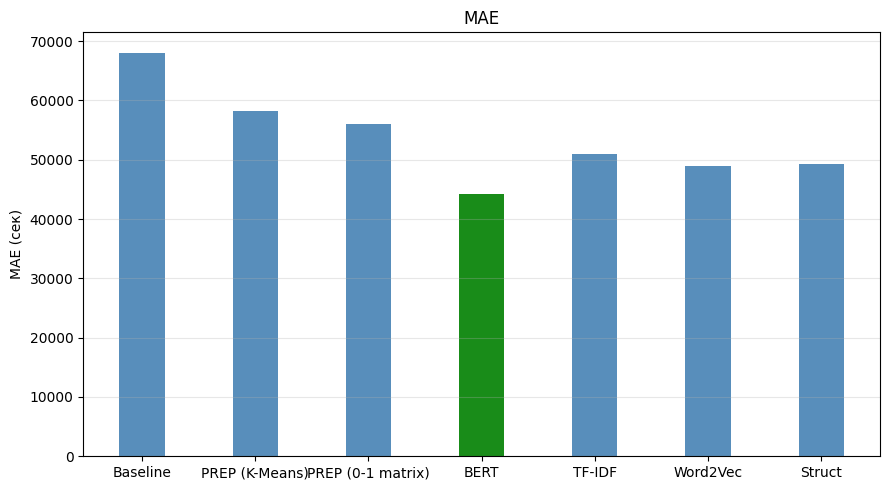

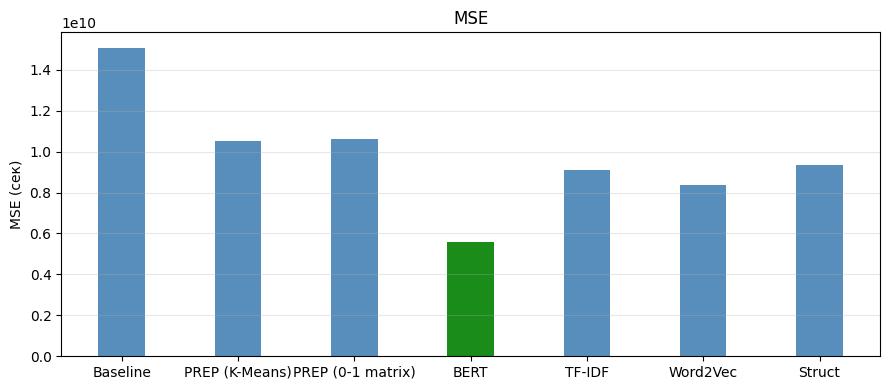

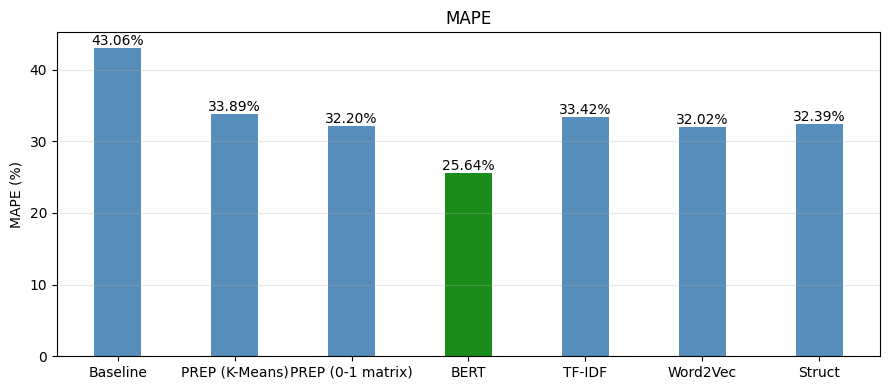

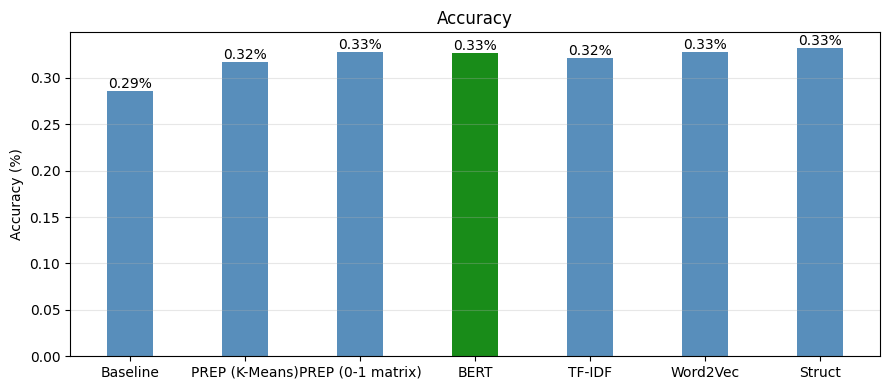

In [5]:
import matplotlib.pyplot as plt
import numpy as np

methods_plot = summary["Модель"].tolist()
mae_plot = summary["MAE"].tolist()
mse_plot = summary["MSE"].tolist()
mape_plot = summary["MAPE"].tolist()
accuracy_plot = summary["Accuracy"].tolist()

x = np.arange(len(methods_plot))
colors = ["steelblue"] * 3 + ["green"] + ["steelblue"] * 6


# ---------------- MAE ----------------
plt.figure(figsize=(9,5))
bars = plt.bar(x, mae_plot, color=colors, alpha=0.9, width=0.4)
plt.xticks(x, methods_plot)
plt.ylabel("MAE (сек)")
plt.title("MAE")
plt.grid(axis="y", alpha=0.3)



plt.tight_layout()
plt.show()


# ---------------- MSE ----------------
plt.figure(figsize=(9,4))
bars = plt.bar(x, mse_plot, color=colors, alpha=0.9, width=0.4)
plt.xticks(x, methods_plot)
plt.ylabel("MSE (сек)")
plt.title("MSE")
plt.grid(axis="y", alpha=0.3)



plt.tight_layout()
plt.show()


# ---------------- MAPE ----------------
plt.figure(figsize=(9,4))
bars = plt.bar(x, mape_plot, color=colors, alpha=0.9, width=0.4)
plt.xticks(x, methods_plot)
plt.ylabel("MAPE (%)")
plt.title("MAPE")
plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, mape_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


# -------------- Accuracy --------------
plt.figure(figsize=(9,4))
bars = plt.bar(x, accuracy_plot, color=colors, alpha=0.9, width=0.4)
plt.xticks(x, methods_plot)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, accuracy_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [6]:
# NOISE ROBUSTNESS: CONFIG
NOISE_CLUSTER_DIR = "noise_clusters"
N_NOISE_RUNS = 5

NOISY_CLUSTER_FILES = {
    "PREP (0-1)": [os.path.join(NOISE_CLUSTER_DIR, f"noise_{i}_prep_01.csv") for i in range(1, N_NOISE_RUNS + 1)],
    "BERT":       [os.path.join(NOISE_CLUSTER_DIR, f"noise_{i}_bert.csv") for i in range(1, N_NOISE_RUNS + 1)],
    "TF-IDF":     [os.path.join(NOISE_CLUSTER_DIR, f"noise_{i}_tfidf.csv") for i in range(1, N_NOISE_RUNS + 1)],
    "Word2Vec":   [os.path.join(NOISE_CLUSTER_DIR, f"noise_{i}_w2v.csv") for i in range(1, N_NOISE_RUNS + 1)],
    # "Struct":   [os.path.join(NOISE_CLUSTER_DIR, f"noise_{i}_struct.csv") for i in range(1, N_NOISE_RUNS + 1)],
}

for model_name, files in NOISY_CLUSTER_FILES.items():
    print(model_name, "->", len(files), "files")

PREP (0-1) -> 5 files
BERT -> 5 files
TF-IDF -> 5 files
Word2Vec -> 5 files


In [7]:
def mean_std_ci95(values):
    vals = np.asarray(values, dtype=float)
    n = len(vals)

    mean_val = np.mean(vals)
    std_val = np.std(vals, ddof=1) if n > 1 else 0.0

    # для 5 прогонов t_{0.975,4} ≈ 2.776
    t_crit = 2.776 if n == 5 else 1.96
    half_ci = t_crit * std_val / np.sqrt(n) if n > 1 else 0.0

    return mean_val, std_val, mean_val - half_ci, mean_val + half_ci

In [8]:
# =========================================
# EVALUATION ON 5 NOISY FILES
# =========================================
noise_results_rows = []
noise_predictions_by_run = {}

for run_id in range(1, N_NOISE_RUNS + 1):
    print(f"\n========================================")
    print(f"NOISE RUN {run_id}")
    print(f"========================================")

    preds_this_run = {}

    for model_name, file_list in NOISY_CLUSTER_FILES.items():
        filepath = file_list[run_id - 1]
        print(f"\n--- {model_name} | file: {filepath}")

        df_clust = pd.read_csv(filepath)

        assert len(df_clust) == len(df_base), f"Size mismatch for {model_name}, run {run_id}"
        if "PathClusterID" not in df_clust.columns:
            raise ValueError(f"{filepath}: no PathClusterID column")

        df_clust["PathClusterID"] = df_clust["PathClusterID"].astype("category")

        feature_cols_clust = feature_cols_base + ["PathClusterID"]
        Xc_train, Xc_test, y_train, y_test = make_splits(df_clust, feature_cols_clust)

        res = build_and_evaluate(
            Xc_train, Xc_test, y_train, y_test,
            desc=f"Noise run {run_id} | {model_name}"
        )

        noise_results_rows.append({
            "run_id": run_id,
            "model": model_name,
            "MAE": res["MAE"],
            "MSE": res["MSE"],
            "MAPE": res["MAPE"],
            "Accuracy": res["Accuracy"]
        })

        preds_this_run[model_name] = res["y_pred"]

    # ансамбль 80:10:10
    y_pred_ens = (
        0.8 * preds_this_run["BERT"] +
        0.1 * preds_this_run["Word2Vec"] +
        0.1 * preds_this_run["PREP (0-1)"]
    )

    mae_ens = mean_absolute_error(y_test, y_pred_ens)
    mse_ens = mean_squared_error(y_test, y_pred_ens)
    mape_ens = mean_absolute_percentage_error(y_test, y_pred_ens) * 100.0

    #noise_results_rows.append({
    #    "run_id": run_id,
    #    "model": "Ensemble 80:10:10",
    #    "MAE": mae_ens,
    #    "MSE": mse_ens,
    #    "MAPE": mape_ens,
    #})

    noise_predictions_by_run[run_id] = preds_this_run

noise_results_df = pd.DataFrame(noise_results_rows)
print(noise_results_df.sort_values(["model", "run_id"]))


NOISE RUN 1

--- PREP (0-1) | file: noise_clusters/noise_1_prep_01.csv

[Noise run 1 | PREP (0-1)]
  Числовые признаки : ['JobIDRaw', 'UID', 'GID', 'ReqNodes', 'ReqCPUS', 'TimelimitRaw', 'Priority', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']
  Категориальные    : ['Partition', 'NodeList', 'Submit', 'WorkDir', 'PathClusterID']
Index([], dtype='object')
  MAE  = 72823.80 сек
  MSE = 16560193109.52 сек
  MAPE = 43.85 сек
  Accuracy = 0.28 %

--- BERT | file: noise_clusters/noise_1_bert.csv

[Noise run 1 | BERT]
  Числовые признаки : ['JobIDRaw', 'UID', 'GID', 'ReqNodes', 'ReqCPUS', 'TimelimitRaw', 'Priority', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']
  Категориальные    : ['Partition', 'NodeList', 'Submit', 'WorkDir', 'PathClusterID']
Index([], dtype='object')
  MAE  = 66191.48 сек
  MSE = 12744877127.58 сек
  MAPE = 41.22 сек
  Accuracy = 0.28 %

--- TF-IDF | file: noise_clusters/noise_1_tfidf.csv

[Noise run 1 | TF-IDF]
  Числовые признаки : ['JobIDRaw', 'UID

In [9]:
# =========================================
# SUMMARY: MEAN + 95% CI
# =========================================
agg_rows = []

for model_name, g in noise_results_df.groupby("model"):
    mae_mean, mae_std, mae_lo, mae_hi = mean_std_ci95(g["MAE"].values)
    mse_mean, mse_std, mse_lo, mse_hi = mean_std_ci95(g["MSE"].values)
    mape_mean, mape_std, mape_lo, mape_hi = mean_std_ci95(g["MAPE"].values)
    accuracy_mean, accuracy_std, accuracy_lo, accuracy_hi = mean_std_ci95(g["Accuracy"].values)

    agg_rows.append({
        "Модель": model_name,

        "MAE_mean": mae_mean,
        "MAE_std": mae_std,
        "MAE_CI95_low": mae_lo,
        "MAE_CI95_high": mae_hi,

        "MSE_mean": mse_mean,
        "MSE_std": mse_std,
        "MSE_CI95_low": mse_lo,
        "MSE_CI95_high": mse_hi,

        "MAPE_mean": mape_mean,
        "MAPE_std": mape_std,
        "MAPE_CI95_low": mape_lo,
        "MAPE_CI95_high": mape_hi,

        "Accuracy_mean": accuracy_mean,
        "Accuracy_std": accuracy_std,
        "Accuracy_CI95_low": accuracy_lo,
        "Accuracy_CI95_high": accuracy_hi,
    })

noise_summary = pd.DataFrame(agg_rows).sort_values("MSE_mean")
print(noise_summary)

       Модель      MAE_mean      MAE_std  MAE_CI95_low  MAE_CI95_high  \
2      TF-IDF  67817.880478  1088.094040  66467.049875   69168.711081   
0        BERT  67008.292783  3556.593783  62592.906292   71423.679274   
3    Word2Vec  69779.496312  6594.011026  61593.262802   77965.729822   
1  PREP (0-1)  73635.064264  1398.269215  71899.162055   75370.966473   

       MSE_mean       MSE_std  MSE_CI95_low  MSE_CI95_high  MAPE_mean  \
2  1.241757e+10  5.809972e+08  1.169628e+10   1.313886e+10  41.629203   
0  1.286448e+10  1.959873e+09  1.043137e+10   1.529760e+10  40.601404   
3  1.486550e+10  3.478111e+09  1.054754e+10   1.918345e+10  43.156704   
1  1.652852e+10  8.224660e+08  1.550746e+10   1.754958e+10  43.813172   

   MAPE_std  MAPE_CI95_low  MAPE_CI95_high  Accuracy_mean  Accuracy_std  \
2  0.839795      40.586627       42.671780       0.275050      0.002918   
0  1.483045      38.760255       42.442552       0.278074      0.001724   
3  3.400982      38.934504       47.378905 

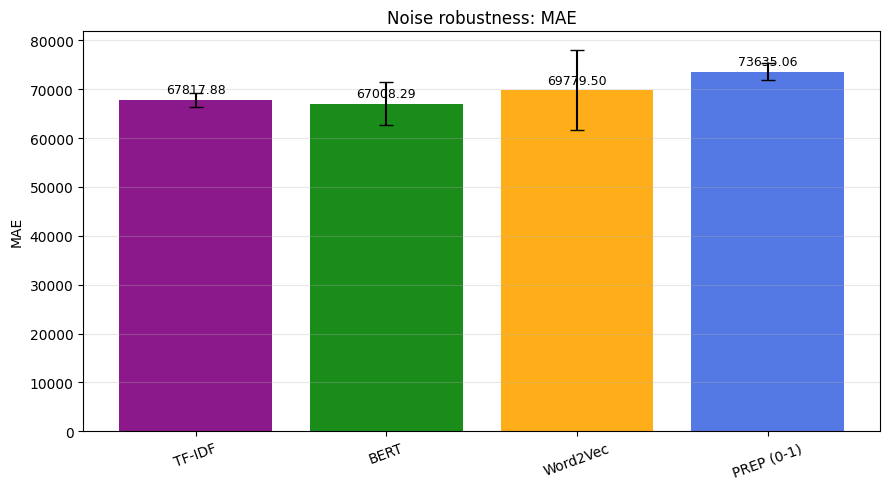

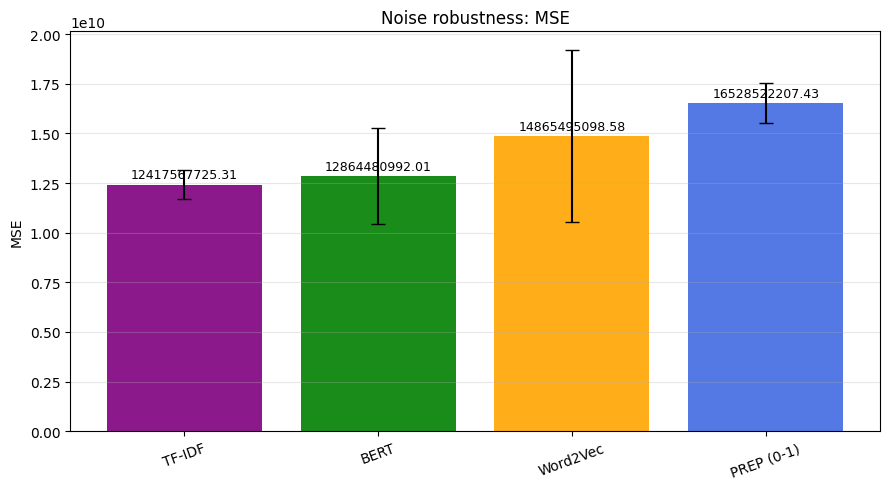

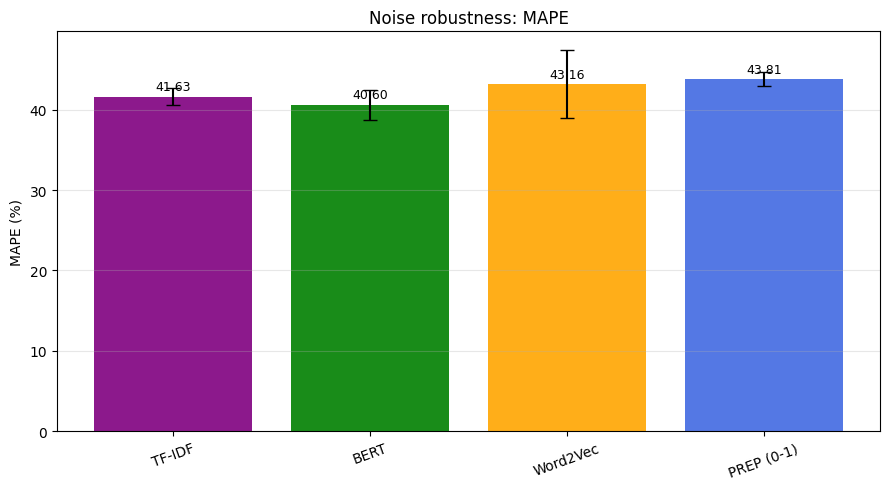

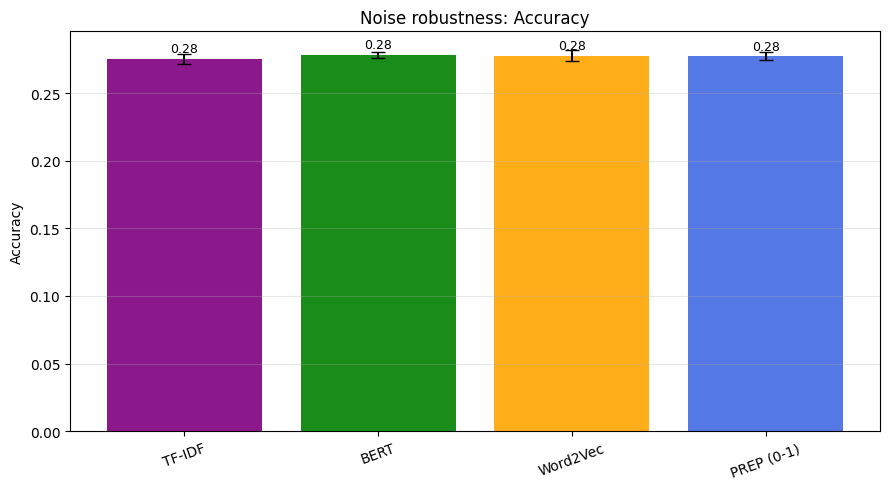

In [10]:
# =========================================
# PLOTS: NOISE ROBUSTNESS
# =========================================
import matplotlib.pyplot as plt

def plot_metric_with_ci(df_summary, mean_col, low_col, high_col, title, ylabel, fmt="{:.2f}"):
    models_plot = df_summary["Модель"].tolist()
    x = np.arange(len(models_plot))

    means = df_summary[mean_col].values
    lows = df_summary[low_col].values
    highs = df_summary[high_col].values
    errs = np.vstack([means - lows, highs - means])

    colors = []
    for m in df_summary["Модель"]:
        if m == "BERT":
            colors.append("green")
        elif m == "Word2Vec":
            colors.append("orange")
        elif m == "PREP (0-1)":
            colors.append("royalblue")
        elif m == "TF-IDF":
            colors.append("purple")
        elif m == "Ensemble 80:10:10":
            colors.append("crimson")
        else:
            colors.append("gray")

    plt.figure(figsize=(9, 5))
    bars = plt.bar(x, means, yerr=errs, capsize=5, color=colors, alpha=0.9)
    plt.xticks(x, models_plot, rotation=20)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.3)

    ymax = np.nanmax(means) if len(means) > 0 else 1.0
    offset = 0.01 * ymax if ymax != 0 else 0.01

    for b, val in zip(bars, means):
        plt.text(
            b.get_x() + b.get_width()/2,
            b.get_height() + offset,
            fmt.format(val),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

plot_metric_with_ci(noise_summary, "MAE_mean", "MAE_CI95_low", "MAE_CI95_high", "Noise robustness: MAE", "MAE")
plot_metric_with_ci(noise_summary, "MSE_mean", "MSE_CI95_low", "MSE_CI95_high", "Noise robustness: MSE", "MSE")
plot_metric_with_ci(noise_summary, "MAPE_mean", "MAPE_CI95_low", "MAPE_CI95_high", "Noise robustness: MAPE", "MAPE (%)")
plot_metric_with_ci(noise_summary, "Accuracy_mean", "Accuracy_CI95_low", "Accuracy_CI95_high", "Noise robustness: Accuracy", "Accuracy")